In [89]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [90]:
df = pd.read_csv("mushroom.csv")

In [91]:
df.head()

,cap-diameter,cap-shape,gill-attachment,gill-color,stem-height,stem-width,stem-color,season,class
0,1372,2,2,10,3.807467,1545,11,1.804273,1
1,1461,2,2,10,3.807467,1557,11,1.804273,1
2,1371,2,2,10,3.612496,1566,11,1.804273,1
3,1261,6,2,10,3.787572,1566,11,1.804273,1
4,1305,6,2,10,3.711971,1464,11,0.943195,1


In [92]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 54035 entries, 0 to 54034
Data columns (total 9 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   cap-diameter     54035 non-null  int64  
 1   cap-shape        54035 non-null  int64  
 2   gill-attachment  54035 non-null  int64  
 3   gill-color       54035 non-null  int64  
 4   stem-height      54035 non-null  float64
 5   stem-width       54035 non-null  int64  
 6   stem-color       54035 non-null  int64  
 7   season           54035 non-null  float64
 8   class            54035 non-null  int64  
dtypes: float64(2), int64(7)
memory usage: 3.7 MB


In [93]:
df.describe()

,cap-diameter,cap-shape,gill-attachment,gill-color,stem-height,stem-width,stem-color,season,class
count,54035.000000,54035.000000,54035.000000,54035.000000,54035.000000,54035.000000,54035.000000,54035.000000,54035.000000
mean,567.257204,4.000315,2.142056,7.329509,0.759110,1051.081299,8.418062,0.952163,0.549181
std,359.883763,2.160505,2.228821,3.200266,0.650969,782.056076,3.262078,0.305594,0.497580
min,0.000000,0.000000,0.000000,0.000000,0.000426,0.000000,0.000000,0.027372,0.000000
25%,289.000000,2.000000,0.000000,5.000000,0.270997,421.000000,6.000000,0.888450,0.000000
50%,525.000000,5.000000,1.000000,8.000000,0.593295,923.000000,11.000000,0.943195,1.000000
75%,781.000000,6.000000,4.000000,10.000000,1.054858,1523.000000,11.000000,0.943195,1.000000
max,1891.000000,6.000000,6.000000,11.000000,3.835320,3569.000000,12.000000,1.804273,1.000000


In [94]:
df.isnull().sum()

,0
cap-diameter,0
cap-shape,0
gill-attachment,0
gill-color,0
stem-height,0
stem-width,0
stem-color,0
season,0
class,0


In [95]:
df.shape

(54035, 9)

In [96]:
df['class'].value_counts()

,count
class,
1,29675
0,24360


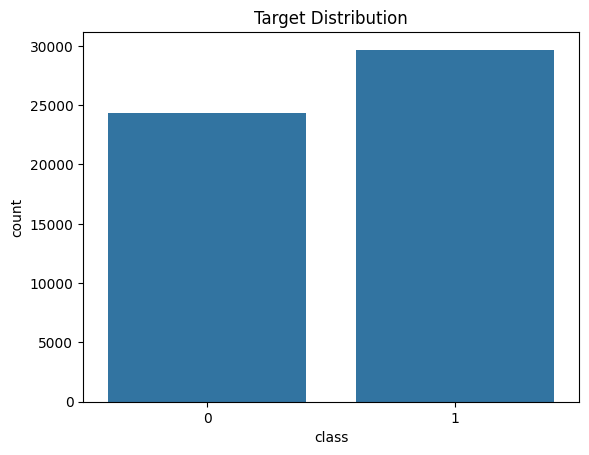

In [97]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.countplot(x='class', data=df)
plt.title("Target Distribution")
plt.show()

edible--0
poisonous--1

In [98]:
for col in df.columns:
    print(f"{col}: {df[col].nunique()} unique values")

cap-diameter: 1847 unique values
cap-shape: 7 unique values
gill-attachment: 7 unique values
gill-color: 12 unique values
stem-height: 1455 unique values
stem-width: 3510 unique values
stem-color: 13 unique values
season: 4 unique values
class: 2 unique values


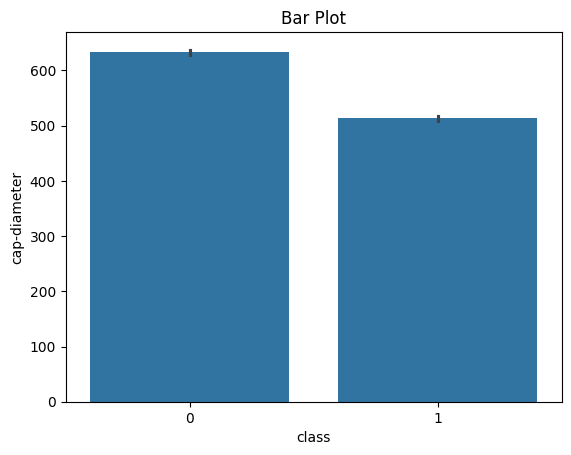

In [99]:
sns.barplot(x='class', y='cap-diameter', data=df)
plt.title("Bar Plot")
plt.show()

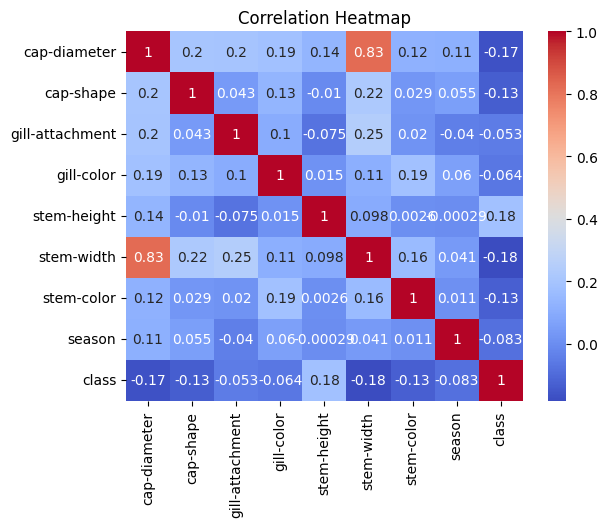

In [100]:
sns.heatmap(df.corr(), annot=True, cmap='coolwarm')
plt.title("Correlation Heatmap")
plt.show()

In [101]:
numerical_cols = df.select_dtypes(include=np.number).columns

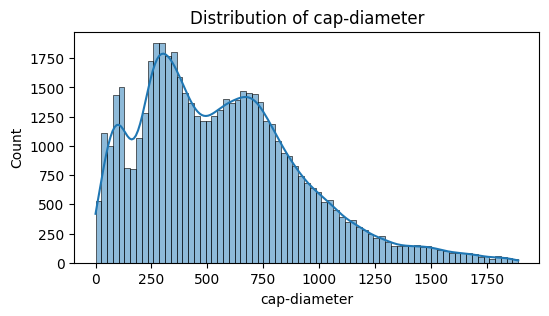

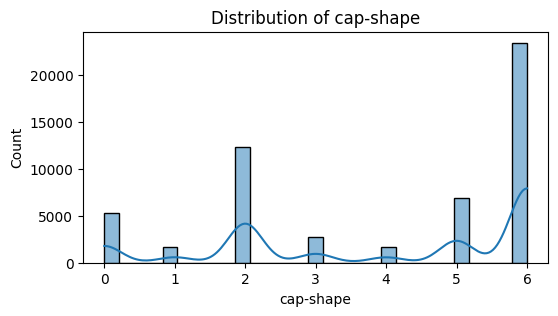

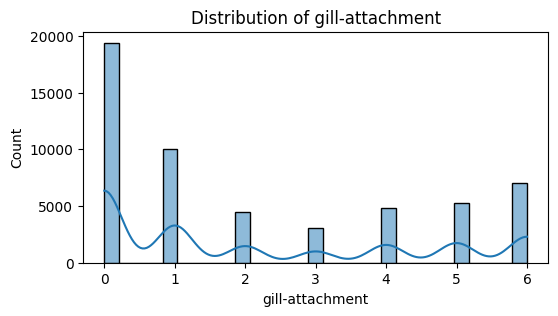

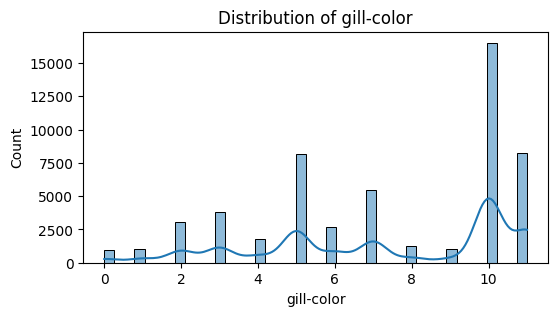

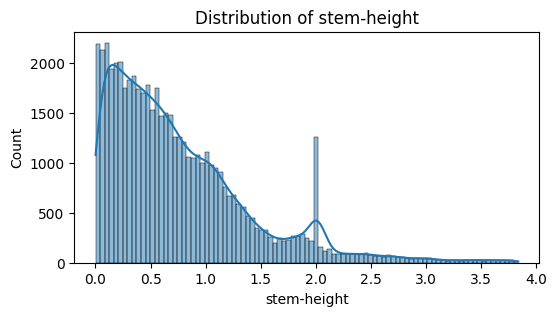

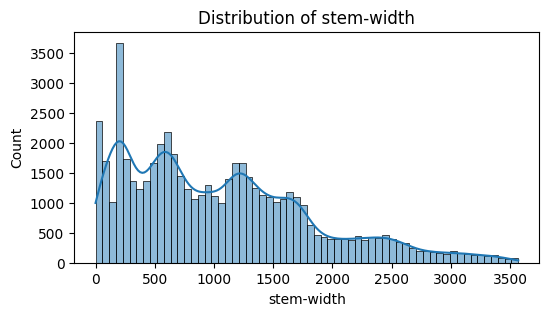

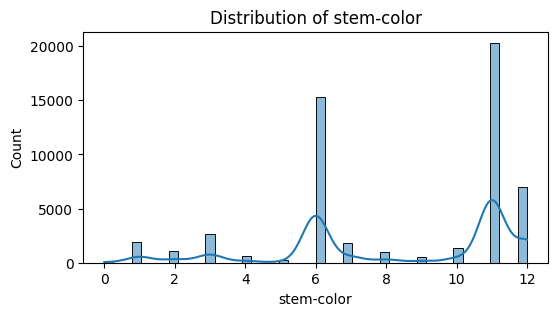

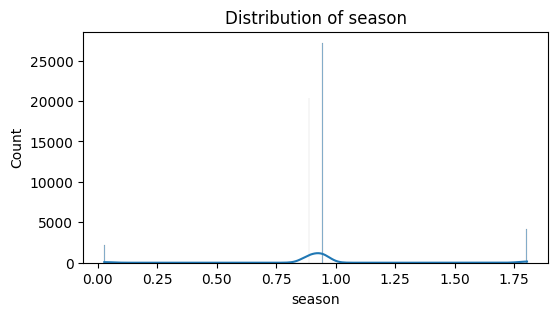

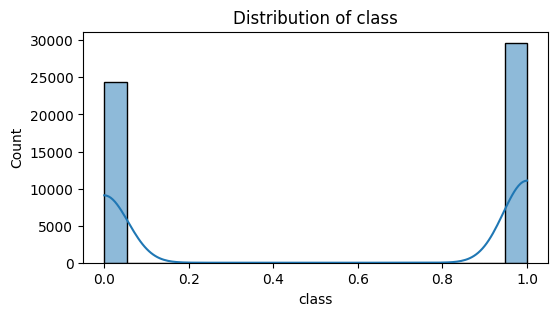

In [102]:
for col in numerical_cols:
    plt.figure(figsize=(6,3))
    sns.histplot(df[col], kde=True)
    plt.title(f"Distribution of {col}")
    plt.show()

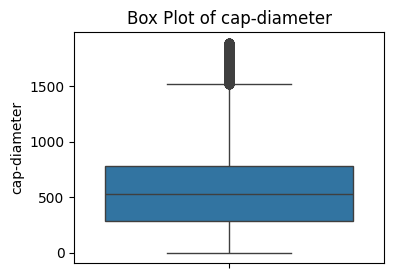

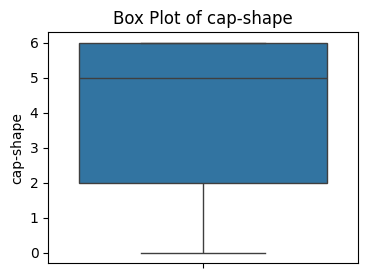

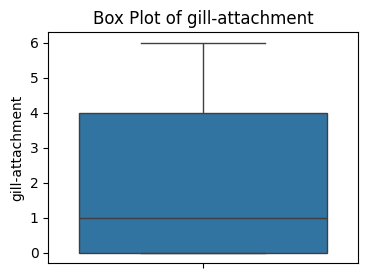

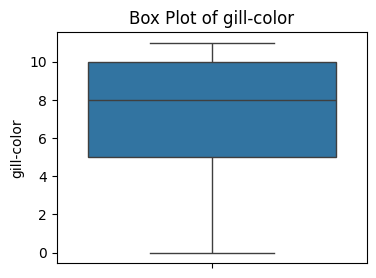

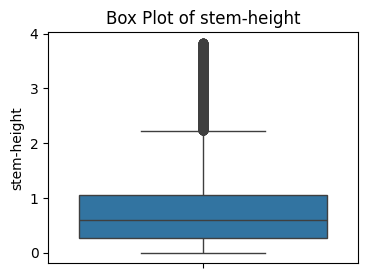

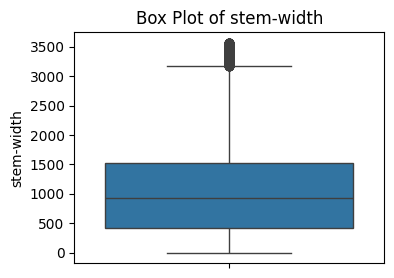

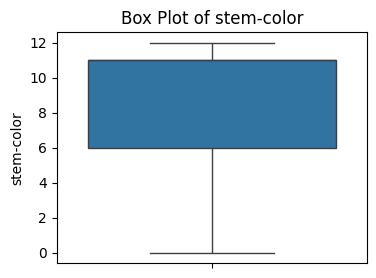

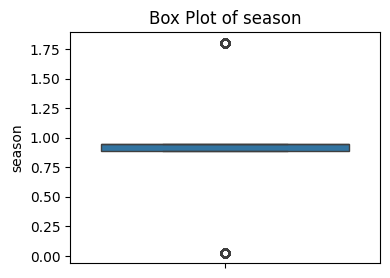

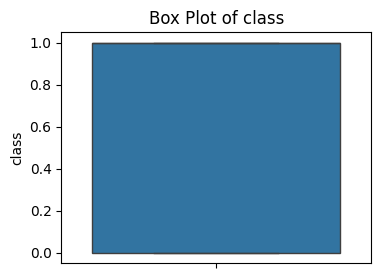

In [103]:
for col in numerical_cols:
    plt.figure(figsize=(4,3))
    sns.boxplot(y=df[col])
    plt.title(f"Box Plot of {col}")
    plt.show()

In [104]:
def cap_outliers_iqr(df, col):
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1

    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR

    df[col] = np.where(df[col] < lower, lower,np.where(df[col] > upper, upper, df[col]))
    return df

In [105]:
for col in numerical_cols:
    df = cap_outliers_iqr(df, col)

In [106]:
df.shape

(54035, 9)

In [107]:
from sklearn.model_selection import train_test_split

In [108]:
X = df.drop('class', axis=1)
y = df['class']

In [109]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

In [110]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

Logistic Regression

In [111]:
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

In [112]:
from sklearn.linear_model import LogisticRegression

lr = LogisticRegression(max_iter=1000)
lr.fit(X_train_scaled, y_train)

y_pred_lr = lr.predict(X_test_scaled)

print("Logistic Regression Accuracy:", accuracy_score(y_test, y_pred_lr))
print(classification_report(y_test, y_pred_lr))

Logistic Regression Accuracy: 0.641898769316184
              precision    recall  f1-score   support

         0.0       0.61      0.56      0.58      4872
         1.0       0.66      0.71      0.69      5935

    accuracy                           0.64     10807
   macro avg       0.64      0.63      0.63     10807
weighted avg       0.64      0.64      0.64     10807



Decision Tree

In [113]:
from sklearn.tree import DecisionTreeClassifier

dt = DecisionTreeClassifier(random_state=42)
dt.fit(X_train_scaled, y_train)

y_pred_dt = dt.predict(X_test_scaled)

print("Decision Tree Accuracy:", accuracy_score(y_test, y_pred_dt))
print(classification_report(y_test, y_pred_dt))

Decision Tree Accuracy: 0.9771444434163042
              precision    recall  f1-score   support

         0.0       0.97      0.98      0.97      4872
         1.0       0.98      0.98      0.98      5935

    accuracy                           0.98     10807
   macro avg       0.98      0.98      0.98     10807
weighted avg       0.98      0.98      0.98     10807



Random Forest

In [114]:
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(n_estimators=100,random_state=42)

rf.fit(X_train_scaled, y_train)

y_pred_rf = rf.predict(X_test_scaled)

print("Random Forest Accuracy:", accuracy_score(y_test, y_pred_rf))
print(classification_report(y_test,y_pred_rf))

Random Forest Accuracy: 0.9898214120477469
              precision    recall  f1-score   support

         0.0       0.99      0.99      0.99      4872
         1.0       0.99      0.99      0.99      5935

    accuracy                           0.99     10807
   macro avg       0.99      0.99      0.99     10807
weighted avg       0.99      0.99      0.99     10807



K NEAREST NEIGHBOR

In [115]:
from sklearn.neighbors import KNeighborsClassifier

knn = KNeighborsClassifier(n_neighbors=5)
knn.fit(X_train_scaled, y_train)
y_knn = knn.predict(X_test_scaled)

print("KNN")
print(classification_report(y_test,y_knn))

KNN
              precision    recall  f1-score   support

         0.0       0.99      0.99      0.99      4872
         1.0       0.99      0.99      0.99      5935

    accuracy                           0.99     10807
   macro avg       0.99      0.99      0.99     10807
weighted avg       0.99      0.99      0.99     10807



In [116]:
accuracies = {
    "Logistic Regression": accuracy_score(y_test, y_pred_lr),
    "Decision Tree": accuracy_score(y_test, y_pred_dt),
    "Random Forest": accuracy_score(y_test, y_pred_rf),
    "KNN": accuracy_score(y_test, y_knn)
}

for model, acc in accuracies.items():
    print(f"{model}: {acc:.4f}")


Logistic Regression: 0.6419
Decision Tree: 0.9771
Random Forest: 0.9898
KNN: 0.9867


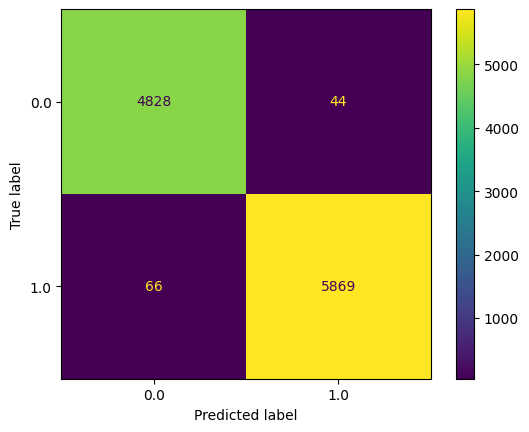

In [117]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

ConfusionMatrixDisplay.from_predictions(y_test, y_pred_rf)
plt.show()

In [118]:
from sklearn.model_selection import RandomizedSearchCV
from sklearn.ensemble import RandomForestClassifier

params = {
    'n_estimators': [200, 500],
    'max_depth': [None, 30],
    'min_samples_leaf': [1, 5],
    'max_features': ['sqrt', 0.5]
}

rs = RandomizedSearchCV(RandomForestClassifier(random_state=42, n_jobs=-1),params,n_iter=10,scoring='roc_auc',cv=5,n_jobs=-1)

rs.fit(X_train_scaled, y_train)
best_rf = rs.best_estimator_

In [119]:
best_rf = rs.best_estimator_
print(best_rf)

RandomForestClassifier(max_features=0.5, n_estimators=500, n_jobs=-1,
                       random_state=42)


In [121]:
import joblib
joblib.dump(rs, "model.pkl", compress=3)

['model.pkl']